## PROJECT: COVID-19 Deaths Analysis: Global Trends and Insights
This project analyzes global COVID-19 death trends using the `time_series_covid19_deaths_global.csv` dataset from Johns Hopkins University. The goal is to nderstand how the pandemic impacted different countries over time, identify key trends, and visualize the data to draw meaningful insights.

## 1. Import the required libraries

In [2]:
# Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load the Dataset

In [3]:
# Load the Data

deaths_rec = pd.read_csv("../data/raw/time_series_covid19_deaths_global.csv")
deaths_rec.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,7896,7896,7896,7896,7896,7896,7896,7896,7896,7896
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,3598,3598,3598,3598,3598,3598,3598,3598,3598,3598
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,6881,6881,6881,6881,6881,6881,6881,6881,6881,6881
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,165,165,165,165,165,165,165,165,165,165
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,1933,1933,1933,1933,1933,1933,1933,1933,1933,1933


## 3. Clean and Preprocess the Data

In [11]:
# Rename Columns
deaths_rec.rename(columns={"Province/State":"State", "Country/Region":"Country"}, inplace=True)
deaths_rec.head()

,State,Country,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,7896,7896,7896,7896,7896,7896,7896,7896,7896,7896
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,3598,3598,3598,3598,3598,3598,3598,3598,3598,3598
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,6881,6881,6881,6881,6881,6881,6881,6881,6881,6881
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,165,165,165,165,165,165,165,165,165,165
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,1933,1933,1933,1933,1933,1933,1933,1933,1933,1933


In [12]:
# Check for Missing Values
print(deaths_rec.isnull().sum())

State      198
Country      0
Lat          2
Long         2
1/22/20      0
          ... 
3/5/23       0
3/6/23       0
3/7/23       0
3/8/23       0
3/9/23       0
Length: 1147, dtype: int64


In [13]:
# Dropped emty cell using dropna()

deaths_drop_missing = deaths_rec.dropna()
deaths_drop_missing.head()

,State,Country,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,2/28/23,3/1/23,3/2/23,3/3/23,3/4/23,3/5/23,3/6/23,3/7/23,3/8/23,3/9/23
9,Australian Capital Territory,Australia,-35.4735,149.0124,0,0,0,0,0,0,...,224,224,228,228,228,228,228,228,228,228
10,New South Wales,Australia,-33.8688,151.2093,0,0,0,0,0,0,...,6464,6464,6493,6493,6493,6493,6493,6493,6493,6529
11,Northern Territory,Australia,-12.4634,130.8456,0,0,0,0,0,0,...,90,90,90,90,90,90,90,90,90,91
12,Queensland,Australia,-27.4698,153.0251,0,0,0,0,0,0,...,2760,2760,2783,2783,2783,2783,2783,2783,2783,2783
13,South Australia,Australia,-34.9285,138.6007,0,0,0,0,0,0,...,1322,1322,1322,1322,1322,1322,1322,1322,1322,1365


In [14]:
# Melt the DataFrame (convert wide format to long format)

deaths_melted = deaths_drop_missing.melt(id_vars=["State", "Country", "Lat", "Long"],
                                    var_name="Date",
                                    value_name="Deaths")
deaths_melted["Date"] = pd.to_datetime(deaths_melted["Date"], format="%m/%d/%y")
deaths_melted.head()

,State,Country,Lat,Long,Date,Deaths
0,Australian Capital Territory,Australia,-35.4735,149.0124,2020-01-22,0
1,New South Wales,Australia,-33.8688,151.2093,2020-01-22,0
2,Northern Territory,Australia,-12.4634,130.8456,2020-01-22,0
3,Queensland,Australia,-27.4698,153.0251,2020-01-22,0
4,South Australia,Australia,-34.9285,138.6007,2020-01-22,0


In [26]:
# Aggregate Data by Country

global_deaths = deaths_melted.groupby(["Country", "Date"]).sum().reset_index()
global_deaths.head()

,Country,Date,State,Lat,Long,Deaths
0,Australia,2020-01-22,Australian Capital TerritoryNew South WalesNor...,-256.8502,1130.8439,0
1,Australia,2020-01-23,Australian Capital TerritoryNew South WalesNor...,-256.8502,1130.8439,0
2,Australia,2020-01-24,Australian Capital TerritoryNew South WalesNor...,-256.8502,1130.8439,0
3,Australia,2020-01-25,Australian Capital TerritoryNew South WalesNor...,-256.8502,1130.8439,0
4,Australia,2020-01-26,Australian Capital TerritoryNew South WalesNor...,-256.8502,1130.8439,0


## 4. Perform Exploratory Data Analysis (EDA)

In [27]:
# # Global Death Trends Over Time:

# global_trends = global_deaths.groupby("Date").sum()


# plt.figure(figsize=(12, 6))
# plt.plot(global_trends.index, global_trends["Deaths"], label="Globals Deaths", color="red")
# plt.title("Global COVID-19 Deaths Over Time")
# plt.xlabel("Date")
# plt.ylabel("Total Deaths")
# plt.legend()
# plt.grid()
# plt.show()

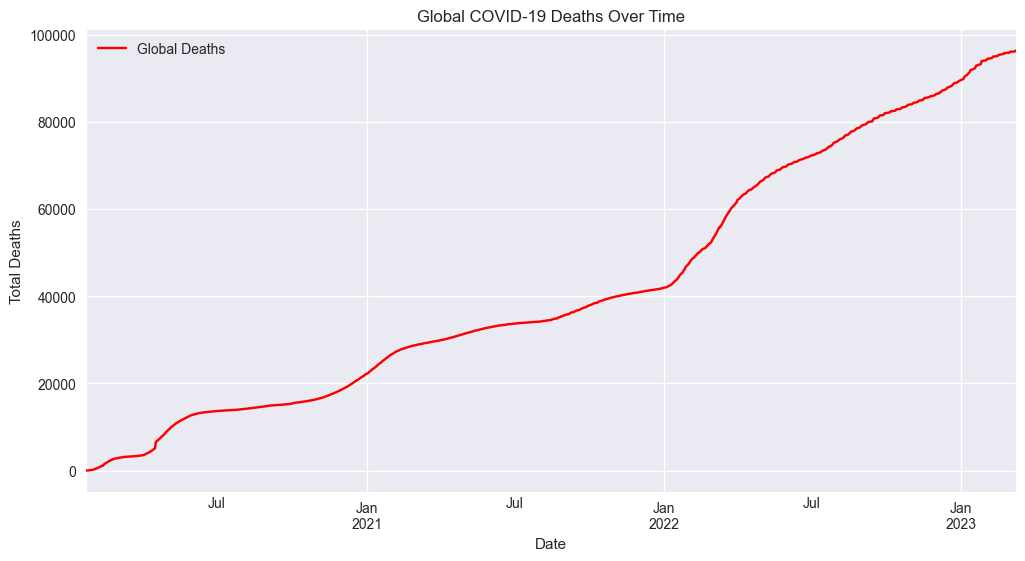

In [31]:
# Global Death Trends Over Time:

global_trends = global_deaths.groupby("Date").sum()

# Set the style
plt.style.use("seaborn-v0_8")

fig, ax = plt.subplots(figsize=(12, 6));
global_trends["Deaths"].plot(ax=ax, c="red", label="Global Deaths")

ax.set(title="Global COVID-19 Deaths Over Time",
       xlabel="Date",
       ylabel="Total Deaths")
ax.legend();

<function matplotlib.pyplot.show(close=None, block=None)>

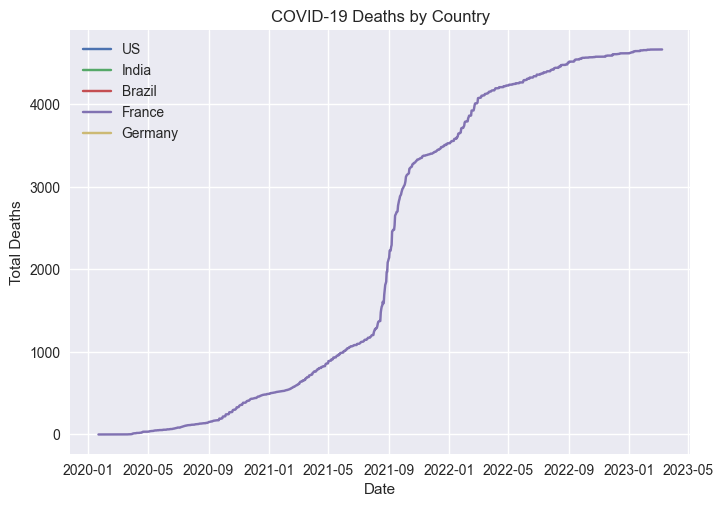

In [49]:
# Compare Deaths Across Countries:
countries = ["US", "India", "Brazil", "France", "Germany"]
for country in countries:
    country_data = global_deaths[global_deaths["Country"] == country]
    # fig, ax = plt.subplots(figsize=(12, 6));
    # ax = country_data.plot(x="Date", y="Deaths", kind="line")
    plt.plot(country_data["Date"], country_data["Deaths"], label=country)

plt.title("COVID-19 Deaths by Country")
plt.xlabel("Date")
plt.ylabel("Total Deaths")
plt.legend()
plt.show